In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

drive.mount('/content/drive')
print("Google Drive подключен.")

sns.set_style("whitegrid")

# Указываем пути к файлам
session_file_path = '/content/drive/MyDrive/Ga_project/ga_sessions.csv'
hits_file_path = '/content/drive/MyDrive/Ga_project/ga_hits.csv'

df_sessions = pd.read_csv(session_file_path, low_memory=False)
df_hits = pd.read_csv(hits_file_path, low_memory=False)
print(f"Файлы прочитаны. Размер df_sessions: {df_sessions.shape}, Размер df_hits: {df_hits.shape}")

# Чистка названий колонок от пробелов
df_sessions.columns = df_sessions.columns.str.strip()
df_hits.columns = df_hits.columns.str.strip()

Mounted at /content/drive
Google Drive подключен.
Файлы прочитаны. Размер df_sessions: (1860042, 18), Размер df_hits: (15726470, 11)


In [2]:
missing_values_sessions = df_sessions.isnull().sum()
missing_percent_sessions = (missing_values_sessions / len(df_sessions) * 100).round(2)
missing_data_report = pd.DataFrame({'Количество пропусков': missing_values_sessions, 'Процент (%)': missing_percent_sessions})
print(missing_data_report.sort_values(by='Процент (%)', ascending=False))

                          Количество пропусков  Процент (%)
device_model                           1843704        99.12
utm_keyword                            1082061        58.17
device_os                              1070138        57.53
device_brand                            367178        19.74
utm_adcontent                           335615        18.04
utm_campaign                            219603        11.81
utm_source                                  97         0.01
session_id                                   0         0.00
client_id                                    0         0.00
visit_number                                 0         0.00
utm_medium                                   0         0.00
visit_date                                   0         0.00
visit_time                                   0         0.00
device_category                              0         0.00
device_screen_resolution                     0         0.00
device_browser                          

In [3]:
missing_values_hits = df_hits.isnull().sum()
missing_percent_hits = (missing_values_hits / len(df_hits) * 100).round(2)
missing_data_report_hits = pd.DataFrame({'Количество пропусков (шт)': missing_values_hits, 'Процент пропусков (%)': missing_percent_hits})
print(missing_data_report_hits.sort_values(by='Процент пропусков (%)', ascending=False))

                Количество пропусков (шт)  Процент пропусков (%)
event_value                      15726470                 100.00
hit_time                          9160322                  58.25
hit_referer                       6274804                  39.90
event_label                       3760184                  23.91
session_id                              0                   0.00
hit_date                                0                   0.00
hit_number                              0                   0.00
hit_page_path                           0                   0.00
hit_type                                0                   0.00
event_action                            0                   0.00
event_category                          0                   0.00


In [4]:
duplicates_sessions = df_sessions.duplicated(subset=['session_id']).sum()
print(f"Дубликатов в sessions: {duplicates_sessions}")

duplicates_hits = df_hits.duplicated().sum()
print(f"Дубликатов в hits: {duplicates_hits}")

Дубликатов в sessions: 0
Дубликатов в hits: 0


In [5]:
# --- 1. Заполнение NaN в оставшихся колонках (используем заглушки) ---
df_sessions.fillna(value={'utm_source': 'unknown', 'utm_campaign': 'none', 'utm_adcontent': 'none',
                          'utm_keyword': 'none', 'device_os': 'unknown', 'device_brand': 'unknown',
                          'device_model': 'unknown', 'device_screen_resolution': 'unknown',
                          'device_browser': 'unknown', 'geo_country': 'unknown', 'geo_city': 'unknown'},
                   inplace=True)

df_hits.fillna(value={'event_action': 'none', 'event_category': 'unknown',
                      'event_label': 'none', 'hit_referer': 'unknown', 'hit_page_path': 'unknown',
                      'hit_time': 'unknown'},
               inplace=True)
print("NaN-значения заполнены.")


# --- 2. Удаление ненужных колонок перед объединением ---
cols_to_drop_sessions = [
    'visit_date',
    'visit_time',
    'client_id',
    'utm_keyword',
    'utm_adcontent',
    'device_os',
    'device_model',
    'device_screen_resolution',
    'device_browser',
    'device_brand'
]
df_sessions_final = df_sessions.drop(columns=cols_to_drop_sessions, errors='ignore').copy()
cols_to_drop_hits = [
    'hit_time',
    'hit_referer',
    'event_category',
    'event_value'
]
df_hits_final = df_hits.drop(columns=cols_to_drop_hits, errors='ignore').copy()
print("Ненужные колонки удалены.")

NaN-значения заполнены.
Ненужные колонки удалены.


In [6]:
# Приводим типы к строкам на всякий случай
df_hits_final['session_id'] = df_hits_final['session_id'].astype(str)
df_sessions_final['session_id'] = df_sessions_final['session_id'].astype(str)

df_merged = pd.merge(
    df_hits_final,
    df_sessions_final,  # Включаем все оставшиеся колонки
    on='session_id',    # Ключ объединения
    how='left'
)
print(f"Таблицы успешно объединены. Размер: {df_merged.shape}")

Таблицы успешно объединены. Размер: (15726470, 14)


In [7]:
# Преобразование даты
df_merged['hit_date'] = pd.to_datetime(df_merged['hit_date'])

# Преобразование в категориальный тип
categorical_cols = ['hit_type', 'device_category', 'geo_country', 'utm_medium']
for col in categorical_cols:
    df_merged[col] = df_merged[col].astype('category')

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 14 columns):
 #   Column           Dtype         
---  ------           -----         
 0   session_id       object        
 1   hit_date         datetime64[ns]
 2   hit_number       int64         
 3   hit_type         category      
 4   hit_page_path    object        
 5   event_action     object        
 6   event_label      object        
 7   visit_number     float64       
 8   utm_source       object        
 9   utm_medium       category      
 10  utm_campaign     object        
 11  device_category  category      
 12  geo_country      category      
 13  geo_city         object        
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 1.2+ GB


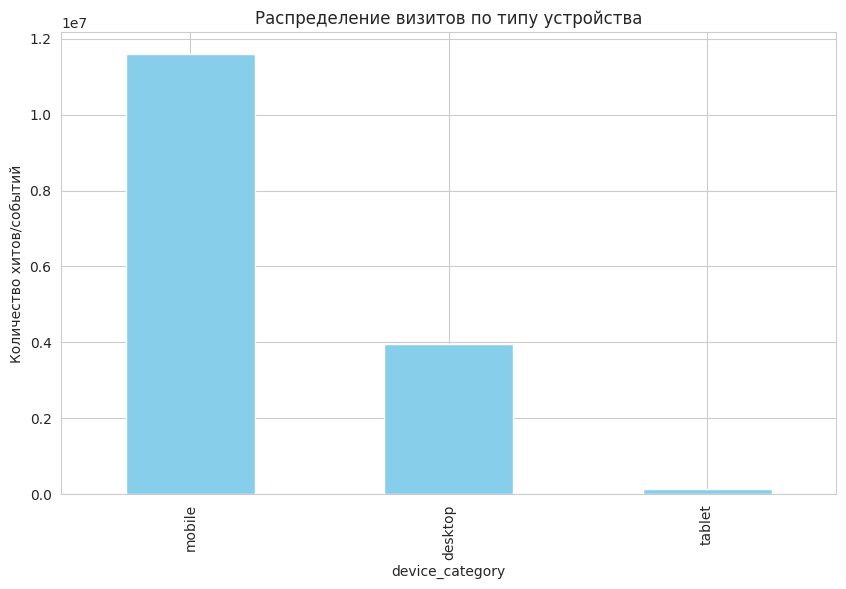

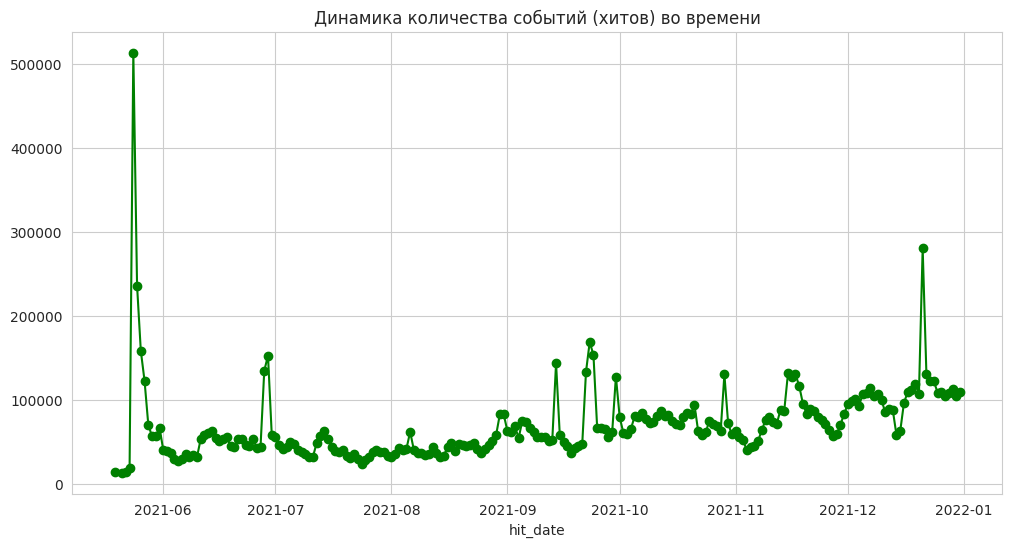

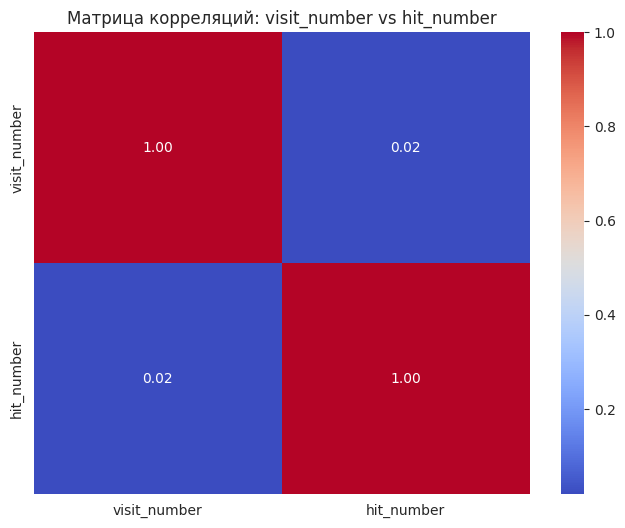

In [8]:
# Визуализация 1: Распределение устройств
plt.figure(figsize=(10, 6))
df_merged['device_category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Распределение визитов по типу устройства')
plt.ylabel('Количество хитов/событий')
plt.show()
# [Вставьте сюда получившийся график]

# Визуализация 2: Динамика событий во времени
df_merged['hit_date'] = pd.to_datetime(df_merged['hit_date'])
hits_per_day = df_merged.groupby(df_merged['hit_date'].dt.date).size()
plt.figure(figsize=(12, 6))
hits_per_day.plot(kind='line', marker='o', color='green')
plt.title('Динамика количества событий (хитов) во времени')
plt.show()
# [Вставьте сюда получившийся график]

# Корреляция: visit_number vs hit_number (требуется приведение типа visit_number)
df_merged['visit_number'] = df_merged['visit_number'].fillna(0).astype(int)
numerical_data = df_merged[['visit_number', 'hit_number']].dropna()
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций: visit_number vs hit_number')
plt.show()
# [Вставьте сюда получившийся график]

# Выводы по корреляции:
# Корреляция между visit_number и hit_number: [Значение из вывода]
# [Ваша текстовая интерпретация результата: сильная/слабая связь и что она значит]


In [9]:
# Это значение очень близко к нулю, что указывает на крайне слабую,
# практически отсутствующую положительную линейную связь между этими двумя переменными.
# Иными словами, порядковый номер визита клиента не оказывает существенного влияния на количество действий,
# которые он совершает во время этого визита.

In [10]:
traffic_column_name = 'traffic_type'

target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click', 'sub_open_dialog_click',
    'sub_custom_question_submit_click', 'sub_call_number_click',
    'sub_callback_submit_click', 'sub_submit_success', 'sub_car_request_submit_click'
]
df_merged['is_target_action'] = df_merged['event_action'].isin(target_actions).astype(int)

organic_mediums = ['organic', 'referral', '(none)']
df_merged[traffic_column_name] = df_merged['utm_medium'].apply(
    lambda x: 'organic' if x in organic_mediums else 'paid'
)

df_merged['traffic_type'] = df_merged['traffic_type'].astype('category')

In [11]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   session_id        object        
 1   hit_date          datetime64[ns]
 2   hit_number        int64         
 3   hit_type          category      
 4   hit_page_path     object        
 5   event_action      object        
 6   event_label       object        
 7   visit_number      int64         
 8   utm_source        object        
 9   utm_medium        category      
 10  utm_campaign      object        
 11  device_category   category      
 12  geo_country       category      
 13  geo_city          object        
 14  is_target_action  int64         
 15  traffic_type      category      
dtypes: category(5), datetime64[ns](1), int64(3), object(7)
memory usage: 1.4+ GB


In [12]:
from scipy import stats
from scipy.stats import levene, ttest_ind

In [13]:
organic_actions = df_merged[df_merged['traffic_type'] == 'organic']['is_target_action']
paid_actions = df_merged[df_merged['traffic_type'] == 'paid']['is_target_action']

levene_test_stat, levene_p_value = stats.levene(organic_actions, paid_actions)

print(f"Levene test p-value: {levene_p_value}")

if levene_p_value < 0.05:
  t_stat, p_value = stats.ttest_ind(organic_actions, paid_actions, equal_var=False)
  test_type = "T-критерий Уэлча"
else:
  t_stat, p_value = stats.ttest_ind(organic_actions, paid_actions, equal_var=True)
  test_type = "T-критерий Стьюдента"

print(f"Используется: {test_type}")
print(f"T-статистика: {t_stat}, P-значение: {p_value}")

Levene test p-value: 1.3673260014068294e-115
Используется: T-критерий Уэлча
T-статистика: 22.43403286360738, P-значение: 1.8426540273422516e-111


конверсия органического трафика отличается от конверсии платного трафика.

In [14]:
mobile_actions = df_merged[df_merged['device_category'] == 'mobile']['is_target_action']
desktop_actions = df_merged[df_merged['device_category'] == 'desktop']['is_target_action']

levene_test_stat, levene_p_value = stats.levene(desktop_actions, mobile_actions)

print(f"Levene test p-value: {levene_p_value}")

if levene_p_value < 0.05:
        # Дисперсии не равны -> T-критерий Уэлча
        t_stat, p_value = stats.ttest_ind(desktop_actions, mobile_actions, equal_var=False)
        test_type = "T-критерий Уэлча"
else:
        # Дисперсии равны -> T-критерий Стьюдента
        t_stat, p_value = stats.ttest_ind(desktop_actions, mobile_actions, equal_var=True)
        test_type = "T-критерий Стьюдента"

print(f"Используется: {test_type}")
print(f"T-статистика: {t_stat}, P-значение: {p_value}")

Levene test p-value: 1.3021525529030945e-06
Используется: T-критерий Уэлча
T-статистика: -4.881007884663981, P-значение: 1.0554736393690667e-06


конверсия мобильного трафика отличается от конверсии десктопного трафика.

In [15]:
print(df_merged['geo_city'].value_counts().head(5))

geo_city
Moscow              6795118
Saint Petersburg    2365520
(not set)            596279
Yekaterinburg        328301
Krasnodar            293501
Name: count, dtype: int64


In [16]:
cities_of_interest = ['Moscow', 'Saint Petersburg']
df_merged['is_local'] = df_merged['geo_city'].isin(cities_of_interest)

group_local = df_merged[df_merged['is_local'] == True]['is_target_action']
group_remote = df_merged[df_merged['is_local'] == False]['is_target_action']

alpha = 0.05
levene_statistic, levene_pvalue = levene(group_local, group_remote)
print(f"P-значение критерия Левене: {levene_pvalue}")

if levene_pvalue > alpha:
        # Дисперсии равны -> Т-критерий Стьюдента (equal_var=True)
        print("\nВывод Левене: Дисперсии равны. Используется Т-критерий Стьюдента.")
        # Распаковываем результат
        t_statistic, t_pvalue = ttest_ind(group_local, group_remote, equal_var=True)
        test_type = "Стьюдента"
else:
        # Дисперсии не равны -> Т-критерий Уэлча (equal_var=False)
        print("\nВывод Левене: Дисперсии не равны. Используется Т-критерий Уэлча.")
        # Распаковываем результат
        t_statistic, t_pvalue = ttest_ind(group_local, group_remote, equal_var=False)
        test_type = "Уэлча"

print(f"Статистика Т-критерия {test_type}: {t_statistic}")
print(f"**P-значение Т-критерия {test_type}: {t_pvalue}**")

P-значение критерия Левене: 5.840703023675372e-131

Вывод Левене: Дисперсии не равны. Используется Т-критерий Уэлча.
Статистика Т-критерия Уэлча: 24.65892974137035
**P-значение Т-критерия Уэлча: 2.97045824494085e-134**


Трафик из городов присутствия (Москва и область, Санкт-Петербург)
отличается от трафика из иных регионов с точки зрения CR
(Conversion Rate) в целевые события.

In [17]:
file_path = '/content/drive/MyDrive/Ga_project/Final_work_reset_memory.csv'
df_merged.to_csv(file_path, index=False)
print(f'Файл успешно сохранен на Google Диск по пути: {file_path}')


Файл успешно сохранен на Google Диск по пути: /content/drive/MyDrive/Ga_project/Final_work_reset_memory.csv


In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from scipy.stats import levene, ttest_ind


merged_file_path = '/content/drive/MyDrive/Ga_project/Final_work_reset_memory.csv'

df_merged = pd.read_csv(merged_file_path, low_memory=False)

In [3]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 17 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   session_id        object
 1   hit_date          object
 2   hit_number        int64 
 3   hit_type          object
 4   hit_page_path     object
 5   event_action      object
 6   event_label       object
 7   visit_number      int64 
 8   utm_source        object
 9   utm_medium        object
 10  utm_campaign      object
 11  device_category   object
 12  geo_country       object
 13  geo_city          object
 14  is_target_action  int64 
 15  traffic_type      object
 16  is_local          bool  
dtypes: bool(1), int64(3), object(13)
memory usage: 1.9+ GB


In [4]:
# Группировка данных по источнику и расчет объема и CR
traffic_by_source = df_merged.groupby('utm_source').agg(
    total_sessions=('session_id', 'count'),
    conversion_rate=('is_target_action', 'mean') # mean() булевых/бинарных значений дает CR
).sort_values(by=['conversion_rate', 'total_sessions'], ascending=False)

print(traffic_by_source.head(10))


                      total_sessions  conversion_rate
utm_source                                           
XzfzEBYZWgSDtJNXOadn              16         0.250000
LIWKeifdTCbuNeniIUqm             372         0.231183
fJCYsujgSxIHFbOmgDdN             170         0.229412
PKriXrefSFPLBYtCRGSE              66         0.166667
JcVHXwVSrnfIuOMMEkrJ               9         0.111111
mtQufDECJCXyKwpKQPvz              90         0.100000
yxJKymlSGVuKIPTxbysx              10         0.100000
DnxUhHWInKVDAWzwROOC             149         0.060403
hONgZhBaHwLGhvJSefNE              18         0.055556
xEbgdGZJlqXAaRmeJQdW              68         0.044118


In [6]:
import pandas as pd

# Предполагается, что df_merged - ваш DataFrame

traffic_summary = df_merged.groupby('utm_source').agg(
    total_sessions=('session_id', 'count'),
    total_target_actions=('is_target_action', 'sum'), # Абсолютный объем целевых действий
    conversion_rate=('is_target_action', 'mean')      # CR (в процентах)
).sort_values(by='total_target_actions', ascending=False) # Сортируем по абсолютному числу конверсий

# Форматируем CR в проценты для удобства чтения
traffic_summary['conversion_rate'] = (traffic_summary['conversion_rate'] * 100).round(2).astype(str) + '%'

print("Топ-10 источников по абсолютному количеству целевых действий:")
print(traffic_summary.head(10))


Топ-10 источников по абсолютному количеству целевых действий:
                      total_sessions  total_target_actions conversion_rate
utm_source                                                                
ZpYIoDJMcFzVoPFsHGJL         5151702                 32242           0.63%
fDLlAcSmythWSCVMvqvL         3250926                 20262           0.62%
kjsLglQLzykiRbcDiGcD         1772431                 13669           0.77%
bByPQxmDaMXgpHeypKSM         1341803                 12235           0.91%
BHcvLfOaCWvWTykYqHVe         1231071                  8342           0.68%
MvfHsxITijuriZxsqZqt          574454                  4307           0.75%
aXQzDWsJuGXeBXexNHjc          386338                  3592           0.93%
QxAxdyPLuQMEcrdZWdWb          443186                  3011           0.68%
jaSOmLICuBzCFqHfBdRg          241057                   838           0.35%
oZCzWSykfixnjMPDNjSU           30141                   483            1.6%


In [7]:
import pandas as pd

# Установим минимальный порог сессий для расчета CR, чтобы исключить статистические аномалии
MIN_SESSIONS_THRESHOLD = 1000

def analyze_traffic(df, group_by_column, threshold):
    """
    Группирует данные, рассчитывает метрики и выводит две отсортированные таблицы:
    одну по объему действий, другую по CR (с порогом).
    """
    print(f"\n\n{'='*60}")
    print(f"НАЧАЛО АНАЛИЗА ПО ПАРАМЕТРУ: '{group_by_column.upper()}'")
    print(f"{'='*60}\n")

    # --- Таблица 1: Рейтинг по объему целевых действий ---
    volume_ranking = df.groupby(group_by_column).agg(
        Объем_сессий=('session_id', 'count'),
        Целевые_действия=('is_target_action', 'sum'),
        CR_процент=('is_target_action', lambda x: round(x.mean() * 100, 2))
    ).sort_values(by='Целевые_действия', ascending=False)

    print(f"--- Таблица 1: Топ-10 по АБСОЛЮТНОМУ ОБЪЕМУ целевых действий ({group_by_column}) ---")
    print(volume_ranking.head(10))
    print("-" * 60)

    # --- Таблица 2: Рейтинг по CR (с фильтром по объему) ---
    # Фильтруем данные, чтобы исключить слишком маленькие группы
    filtered_df = df.groupby(group_by_column).filter(lambda x: len(x) >= threshold)

    if not filtered_df.empty:
        cr_ranking = filtered_df.groupby(group_by_column).agg(
            Объем_сессий=('session_id', 'count'),
            Целевые_действия=('is_target_action', 'sum'),
            CR_процент=('is_target_action', lambda x: round(x.mean() * 100, 2))
        ).sort_values(by='CR_процент', ascending=False)

        print(f"--- Таблица 2: Топ-10 по КОЭФФИЦИЕНТУ КОНВЕРСИИ (CR %) ({group_by_column}) ---")
        print(f"(Показаны только группы с объемом > {threshold} сессий)")
        print(cr_ranking.head(10))
        print("-" * 60)
    else:
        print(f"Недостаточно данных для расчета CR рейтинга с порогом > {threshold} сессий.")


# --- Запуск анализа для всех нужных атрибутов ---

# 1. Анализ по Источникам трафика
analyze_traffic(df_merged, 'utm_source', MIN_SESSIONS_THRESHOLD)

# 2. Анализ по Кампаниям
# Кампаний может быть очень много, фильтр по объему здесь особенно важен
analyze_traffic(df_merged, 'utm_campaign', MIN_SESSIONS_THRESHOLD)

# 3. Анализ по Устройствам
# Устройств обычно мало (mobile, desktop, tablet), порог в 1000 сессий легко пройдет
analyze_traffic(df_merged, 'device_category', MIN_SESSIONS_THRESHOLD)

# 4. Анализ по Странам (Локациям)
analyze_traffic(df_merged, 'geo_country', MIN_SESSIONS_THRESHOLD)

# Примечание: Если нужна детализация по городам, замените 'geo_country' на 'geo_city' в последнем вызове.




НАЧАЛО АНАЛИЗА ПО ПАРАМЕТРУ: 'UTM_SOURCE'

--- Таблица 1: Топ-10 по АБСОЛЮТНОМУ ОБЪЕМУ целевых действий (utm_source) ---
                      Объем_сессий  Целевые_действия  CR_процент
utm_source                                                      
ZpYIoDJMcFzVoPFsHGJL       5151702             32242        0.63
fDLlAcSmythWSCVMvqvL       3250926             20262        0.62
kjsLglQLzykiRbcDiGcD       1772431             13669        0.77
bByPQxmDaMXgpHeypKSM       1341803             12235        0.91
BHcvLfOaCWvWTykYqHVe       1231071              8342        0.68
MvfHsxITijuriZxsqZqt        574454              4307        0.75
aXQzDWsJuGXeBXexNHjc        386338              3592        0.93
QxAxdyPLuQMEcrdZWdWb        443186              3011        0.68
jaSOmLICuBzCFqHfBdRg        241057               838        0.35
oZCzWSykfixnjMPDNjSU         30141               483        1.60
------------------------------------------------------------
--- Таблица 2: Топ-10 по КОЭФФИЦИЕНТ

In [9]:
import pandas as pd

# 1. Определяем список ID источников социальных сетей
social_sources_list = [
    'QxAxdyPLuQMEcrdZWdWb',
    'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICjvs',
    'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWfYjYnfw',
    'gVRrcxiDQubJiljoTbGm'
]

# 2. Фильтруем основной DataFrame, оставляя только визиты из указанных соцсетей
df_social = df_merged[df_merged['utm_source'].isin(social_sources_list)]

print(f"Общее количество визитов из социальных сетей (по указанным ID): {len(df_social)}")

# 3. Агрегируем данные для получения общих метрик по всем соцсетям сразу
if not df_social.empty:

    # Используем одну операцию groupby().agg() для создания DataFrame с нужными столбцами сразу
    social_summary_df = df_social.groupby('utm_source').agg(
        Total_Sessions=('session_id', 'count'),
        Total_Target_Actions=('is_target_action', 'sum'),
        # CR_процент уже рассчитан как среднее и округлен
        CR_percent=( 'is_target_action', lambda x: round(x.mean() * 100, 2))
    )

    print("\n--- Детализация метрик по каждому источнику соцсетей ---")
    # Сортируем для наглядности по CR
    print(social_summary_df.sort_values(by='CR_percent', ascending=False))

    # --- Сводные метрики по ВСЕМ соцсетям вместе ---
    total_sessions_all = social_summary_df['Total_Sessions'].sum()
    total_actions_all = social_summary_df['Total_Target_Actions'].sum()
    overall_cr = round((total_actions_all / total_sessions_all) * 100, 2)

    print("\n--- СВОДНЫЙ АНАЛИЗ ТРАФИКА ИЗ СОЦИАЛЬНЫХ СЕТЕЙ (ВСЕ ВМЕСТЕ) ---")
    print(f"Общий объем сессий: {total_sessions_all}")
    print(f"Всего целевых действий: {total_actions_all}")
    print(f"Общий Коэффициент Конверсии (CR): {overall_cr}%")

else:
    print("\nВ вашем DataFrame 'df_merged' не найдено визитов с указанными utm_source ID.")



Общее количество визитов из социальных сетей (по указанным ID): 1137352

--- Детализация метрик по каждому источнику соцсетей ---
                      Total_Sessions  Total_Target_Actions  CR_percent
utm_source                                                            
IZEXUFLARCUMynmHNBGo           44710                   336        0.75
MvfHsxITijuriZxsqZqt          574454                  4307        0.75
QxAxdyPLuQMEcrdZWdWb          443186                  3011        0.68
gVRrcxiDQubJiljoTbGm           30537                   150        0.49
PlbkrSYoHuZBWfYjYnfw           44465                    74        0.17

--- СВОДНЫЙ АНАЛИЗ ТРАФИКА ИЗ СОЦИАЛЬНЫХ СЕТЕЙ (ВСЕ ВМЕСТЕ) ---
Общий объем сессий: 1137352
Всего целевых действий: 7878
Общий Коэффициент Конверсии (CR): 0.69%


Вопрос: Стоит ли нам увеличивать своё присутствие в соцсетях и давать там больше рекламы?
Ответ: Скорее да, но подходить к этому нужно дифференцированно.
Аргументация:
Канал рабочий, но требует оптимизации: Общий CR в 0,69% показывает, что пользователи из соцсетей конвертируются. Однако это средний показатель.
Эффективность сильно разнится: Два источника (IZEXUFLARCUMynmHNBGo и MvfHsxITijuriZxsqZqt) показывают CR выше среднего (0,75%). В то же время источник PlbkrSYoHuB... имеет очень низкий CR (0,17%), что, вероятно, говорит о неэффективном использовании бюджета на этой площадке.

1. Масштабировать успешные каналы (где CR высокий)
Увеличить рекламное присутствие и бюджет в источниках IZEXUFLARCUMynmHNBGo и MvfHsxITijuriZxsqZqt. Эти площадки приносят наиболее целевой трафик.

2. Оптимизировать или приостановить неэффективные каналы
Пристально проанализировать источник PlbkrSYoHuB.... CR в 0,17% очень низкий. Необходимо проверить:
Корректно ли настроен таргетинг?

3. Улучшить общий CR
Сравнить этот CR (0,69%) со средним CR по сайту. Если средний CR по сайту, например, 1.5%, то соцсети еще сильно отстают, и есть большой потенциал роста за счет улучшения качества трафика или пользовательского опыта на сайте для этой аудитории.



In [10]:
top_paths = df_merged['hit_page_path'].value_counts().head(30)

print("Топ-30 самых посещаемых hit_page_path:")
for path, count in top_paths.items():
    print(f"Путь: {path} | Хитов: {count}")


Топ-30 самых посещаемых hit_page_path:
Путь: podpiska.sberauto.com/ | Хитов: 2793639
Путь: sberauto.com/cars?city=1&rental_page=rental_only&rental_car=rental_only&city=18 | Хитов: 1103484
Путь: sberauto.com/cars?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=LEoPHuyFvzoNfnzGgfcd&utm_content_initial=vCIpmpaGBnIQhyYNkXqp&city=1&rental_page=rental_only&rental_car=rental_only&city=18 | Хитов: 754215
Путь: sberauto.com/cars/f28947a1?rental_page=rental_car | Хитов: 264878
Путь: sberauto.com/cars/bf24b977?rental_page=rental_car | Хитов: 263966
Путь: sberauto.com/cars?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=LEoPHuyFvzoNfnzGgfcd&city=1&rental_page=rental_only&rental_car=rental_only&city=18 | Хитов: 257588
Путь: sberauto.com/cars?city=1&city=18&rental_page=rental_only&rental_car=rental_only&page=1 | Хитов: 199098
Путь: sberauto.com/cars/bfc21661?rental_page=rental_car | Хитов: 187602
Путь: sberauto.com/cars/2fc745ed?rental_page=rental_car | 

In [13]:
import pandas as pd
import numpy as np

# 1. Извлекаем Марку и Модель из URL (используем тот же подход)
df_auto = df_merged[df_merged['hit_page_path'].str.contains('/cars/all/', na=False)].copy()
regex_pattern = r'sberauto\.com/cars/all/([^/]+)/([^/]+)/'
df_auto[['auto_brand', 'auto_model']] = df_auto['hit_page_path'].str.extract(regex_pattern)
df_auto.dropna(subset=['auto_brand', 'auto_model'], inplace=True)
df_auto['full_model_name'] = df_auto['auto_brand'] + ' ' + df_auto['auto_model']


# 2. Агрегируем данные на уровне СЕССИИ (как требует глоссарий)

# Определяем для каждой сессии, была ли она конверсионной (максимум is_target_action в сессии)
session_level_data = df_auto.groupby(['session_id', 'full_model_name']).agg(
    is_converted=('is_target_action', 'max'), # max(0, 1, 1) = 1 (конверсия была)
    session_views=('session_id', 'count') # считаем сколько хитов было в сессии на этой модели
).reset_index()


# 3. Агрегируем данные на уровне АВТОМОБИЛЯ (используем данные сессий)

auto_analysis_session = session_level_data.groupby('full_model_name').agg(
    Уникальные_сессии=('session_id', 'count'),
    Конверсионные_сессии=('is_converted', 'sum'),
    CR_процент=('is_converted', 'mean') # Среднее по 0/1 дает CR сессий
)

# Форматируем CR в проценты
auto_analysis_session['CR_процент'] = (auto_analysis_session['CR_процент'] * 100).round(2)


# --- Таблица 1: Топ-10 самых популярных авто (по объему уникальных сессий) ---
popular_autos_session = auto_analysis_session.sort_values(by='Уникальные_сессии', ascending=False)
print("\n--- Таблица 1: Топ-10 популярных авто (по объему УНИКАЛЬНЫХ СЕССИЙ / интереса) ---")
print(popular_autos_session[['Уникальные_сессии', 'Конверсионные_сессии', 'CR_процент']].head(10))

print("-" * 100)

# --- Таблица 2: Топ-10 самых востребованных авто (по CR сессий / реальному спросу) ---
MIN_SESSIONS_THRESHOLD = 50
cr_autos_session = auto_analysis_session[auto_analysis_session['Уникальные_сессии'] >= MIN_SESSIONS_THRESHOLD].sort_values(by='CR_процент', ascending=False)

print(f"\n--- Таблица 2: Топ-10 востребованных авто (лучший CR сессий, при объеме > {MIN_SESSIONS_THRESHOLD} сессий) ---")
print(cr_autos_session[['Уникальные_сессии', 'Конверсионные_сессии', 'CR_процент']].head(10))




--- Таблица 1: Топ-10 популярных авто (по объему УНИКАЛЬНЫХ СЕССИЙ / интереса) ---
                        Уникальные_сессии  Конверсионные_сессии  CR_процент
full_model_name                                                            
skoda rapid                         56678                  2623        4.63
lada-vaz vesta                      49176                  2415        4.91
volkswagen polo                     40952                  2060        5.03
skoda karoq                         25490                   615        2.41
mercedes-benz e-klasse              22670                   548        2.42
nissan qashqai                      20449                   389        1.90
nissan x-trail                      11699                   221        1.89
kia rio                             11522                   632        5.49
renault duster                      10848                   175        1.61
skoda octavia                       10076                   380        3.77
----